# 3. Exploratory Data Analysis

This notebook explores the cleaned healthcare encounter data to identify patterns related to insurance verification, registration issues, claim denials, and financial impact.

The objective is to uncover actionable insights that may help reduce preventable denials and improve front-end registration quality.

In [12]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None) # show all the columns
pd.set_option("display.max_rows", 20) # show 20 rows

In [13]:
# Load the cleaned encounter dataset.
df = pd.read_csv("cleaned_encounters.csv")

# Convert Encounter_Date back to datetime after reading the CSV.
df["Encounter_Date"] = pd.to_datetime(df["Encounter_Date"])

## Dataset overview

Before beginning the analysis, I confirmed the dataset dimensions, column structure, and key field formats.

In [14]:
df.shape

(2500, 17)

In [15]:
# Preview the cleaned dataset.
df.head()

,Encounter_ID,Encounter_Date,Department,Visit_Type,Payer_Group,Front_End_Issue,RTE_Status,Coverage_Active,COB_Review_Status,Pre_Registration_Complete,Corrected_Before_Billing,Claim_Denied,Denial_Reason,Allowed_Amount,Denied_Amount,Copay_Due,Copay_Collected
0,ENC00105,2026-02-15,Primary Care,Imaging,Commercial,No Front-End Issue,Verified,Yes,Not Applicable,Yes,Not Applicable,No,No Denial,1165.11,0.0,50.78,50.78
1,ENC00964,2026-01-28,OB/GYN,Office Visit,Medicaid,No Front-End Issue,Verified,Yes,Completed,Yes,Not Applicable,No,No Denial,128.36,0.0,0.00,0.00
2,ENC01970,2025-09-16,Cardiology,Follow-up,Medicare,Eligibility Not Verified,Unverified,Yes,Not Applicable,No,No,No,No Denial,214.66,0.0,0.00,0.00
3,ENC02282,2026-01-22,Primary Care,Follow-up,Commercial,No Front-End Issue,Verified,Yes,Not Applicable,Yes,Not Applicable,No,No Denial,163.20,0.0,0.00,0.00
4,ENC01957,2025-12-01,Imaging,Office Visit,Medicaid,No Front-End Issue,Verified,Yes,Not Applicable,Yes,Not Applicable,No,No Denial,254.44,0.0,0.00,0.00


In [16]:
# Confirm the date range covered by the dataset.
print("Start date:", df["Encounter_Date"].min())
print("End date:", df["Encounter_Date"].max())

Start date: 2025-07-01 00:00:00
End date: 2026-06-30 00:00:00


### Result

The cleaned dataset contains **2,500 outpatient encounters** and **17 variables**.

The records cover a 12-month period from **July 1, 2025 through June 30, 2026**.

The dataset includes encounter characteristics, payer information, front-end registration issues, eligibility status, claim outcomes, denied amounts, and copay collection data.

## 3.1 What is the overall claim denial rate?

Before investigating specific denial patterns, it is important to understand how frequently claims were denied in the dataset.

In [17]:
# Count denied and non-denied claims.
claim_outcomes = df["Claim_Denied"].value_counts()

claim_outcomes

Claim_Denied
No     2202
Yes     298
Name: count, dtype: int64

In [18]:
# Calculate overall denial metrics.
total_encounters = len(df)
denied_claims = (df["Claim_Denied"] == "Yes").sum()
denial_rate = denied_claims / total_encounters * 100

print(f"Total encounters: {total_encounters:,}")
print(f"Denied claims: {denied_claims:,}")
print(f"Overall denial rate: {denial_rate:.2f}%")

Total encounters: 2,500
Denied claims: 298
Overall denial rate: 11.92%


In [19]:
# Calculate the financial impact of denied claims.
total_denied_amount = df["Denied_Amount"].sum()

average_denied_amount = (
    df.loc[df["Claim_Denied"] == "Yes", "Denied_Amount"]
    .mean()
)

print(f"Total denied amount: ${total_denied_amount:,.2f}")
print(f"Average denied amount per denied claim: ${average_denied_amount:,.2f}")

Total denied amount: $112,806.77
Average denied amount per denied claim: $378.55


### Result

Among 2,500 outpatient encounters, **298 claims were denied**, resulting in an overall denial rate of **11.92%**.

The denied claims represented a total financial impact of **`$112,806.77`**, with an average denied amount of approximately **`$378.55` per denied claim**.

### Business insight

Approximately one in every eight encounters resulted in a denied claim.

Although most claims were processed successfully, the denied encounters created more than **$112,000 in delayed or at-risk reimbursement** during the 12-month period.

The next step is to determine whether this impact is concentrated in a small number of preventable denial reasons and front-end registration issues.

## 3.2 Which denial reasons contribute most to denied claims?

Overall denial rate alone does not explain where the problem originates.

This section identifies the denial reasons that contribute most to denied claims and the associated financial impact.

In [20]:
# Keep only denied encounters.
denied_df = df[df["Claim_Denied"] == "Yes"]

denied_df.shape

(298, 17)

In [21]:
# Count denied claims by denial reason.
denial_reason_counts = (
    denied_df["Denial_Reason"]
    .value_counts()
)

denial_reason_counts

Denial_Reason
Other Insurance Should Be Primary                87
Coverage Inactive on Date of Service             80
Other Non-Preventable Denial                     48
Eligibility/Benefit Information Not Confirmed    33
Member Identification Mismatch                   29
Subscriber Demographic Mismatch                  21
Name: count, dtype: int64

In [22]:
# Calculate percentage of denied claims by denial reason.
denial_reason_pct = (
    denied_df["Denial_Reason"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

denial_reason_pct

Denial_Reason
Other Insurance Should Be Primary                29.2
Coverage Inactive on Date of Service             26.8
Other Non-Preventable Denial                     16.1
Eligibility/Benefit Information Not Confirmed    11.1
Member Identification Mismatch                    9.7
Subscriber Demographic Mismatch                   7.0
Name: proportion, dtype: float64

In [23]:
# Combine counts and percentages into one table.
denial_summary = pd.concat(
    [
        denial_reason_counts,
        denial_reason_pct
    ],
    axis=1
)

denial_summary.columns = [
    "Denied Claims",
    "Percent (%)"
]

denial_summary

,Denied Claims,Percent (%)
Denial_Reason,,
Other Insurance Should Be Primary,87,29.2
Coverage Inactive on Date of Service,80,26.8
Other Non-Preventable Denial,48,16.1
Eligibility/Benefit Information Not Confirmed,33,11.1
Member Identification Mismatch,29,9.7
Subscriber Demographic Mismatch,21,7.0


### Result

Among the **298 denied claims**, the denial reasons were highly concentrated.

The two most common denial reasons were:

- **Other Insurance Should Be Primary** — **87 claims (29.2%)**
- **Coverage Inactive on Date of Service** — **80 claims (26.8%)**

Together, these two categories accounted for **56.0%** of all denied claims.

The remaining denied claims were distributed across several less frequent reasons, including **Other Non-Preventable Denial (16.1%)**, **Eligibility/Benefit Information Not Confirmed (11.1%)**, **Member Identification Mismatch (9.7%)**, and **Subscriber Demographic Mismatch (7.0%)**.

A bar chart provides a clearer view of which denial reasons contribute most to denied claims.

In [29]:
import matplotlib.pyplot as plt

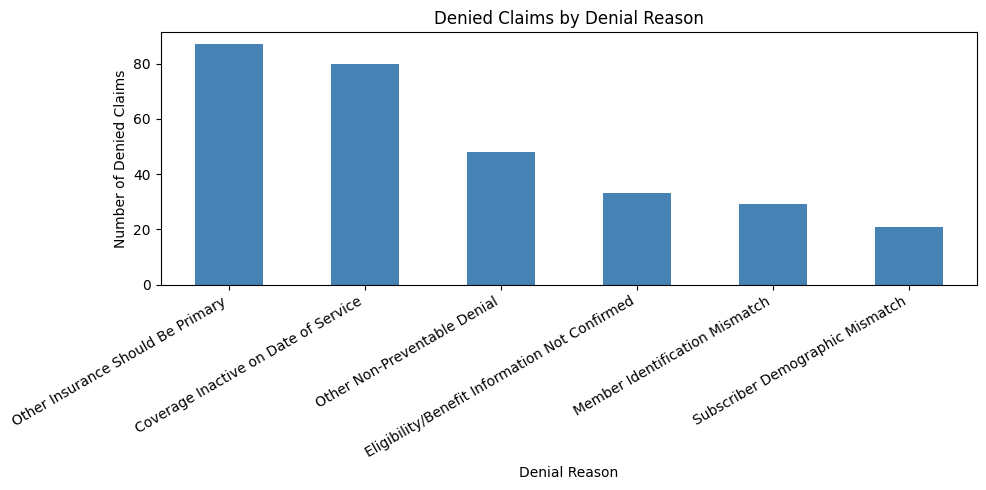

In [32]:
# Plot denied claims by denial reason.


plt.figure(figsize=(10,5))

denial_reason_counts.plot(kind="bar",
                         color="steelblue")

plt.title("Denied Claims by Denial Reason")
plt.xlabel("Denial Reason")
plt.ylabel("Number of Denied Claims")

plt.xticks(rotation=30, ha="right")

plt.tight_layout() #自动调整边距，防止标签被截断

plt.show()

## 3.3 Which departments have the highest denial rate?

Different departments may experience different denial rates due to variations in patient populations, insurance types, and registration workflows.

Comparing denial rates across departments helps identify areas where targeted process improvements may have the greatest impact.

In [33]:
# Count total encounters by department.
department_total = (
    df.groupby("Department")
      .size()
)

department_total

Department
Cardiology      407
Imaging         347
OB/GYN          534
Orthopedics     359
Primary Care    853
dtype: int64

In [34]:
# Count denied claims by department.
department_denied = (
    df[df["Claim_Denied"] == "Yes"]
      .groupby("Department")
      .size()
)

department_denied

Department
Cardiology       60
Imaging          38
OB/GYN           48
Orthopedics      44
Primary Care    108
dtype: int64

In [35]:
# Calculate denial rate by department.
department_denial_rate = (
    department_denied
    / department_total
    * 100
).round(2)

department_denial_rate.sort_values(ascending=False)

Department
Cardiology      14.74
Primary Care    12.66
Orthopedics     12.26
Imaging         10.95
OB/GYN           8.99
dtype: float64

To provide complete context, I combined the total encounter count, denied claim count, and denial rate into a single summary table for comparison across departments.

In [36]:
# Combine department statistics into one summary table.
department_summary = pd.concat(
    [
        department_total,
        department_denied,
        department_denial_rate
    ],
    axis=1
)

department_summary.columns = [
    "Total Encounters",
    "Denied Claims",
    "Denial Rate (%)"
]

department_summary = department_summary.sort_values(
    "Denial Rate (%)",
    ascending=False
)

department_summary

,Total Encounters,Denied Claims,Denial Rate (%)
Department,,,
Cardiology,407,60,14.74
Primary Care,853,108,12.66
Orthopedics,359,44,12.26
Imaging,347,38,10.95
OB/GYN,534,48,8.99


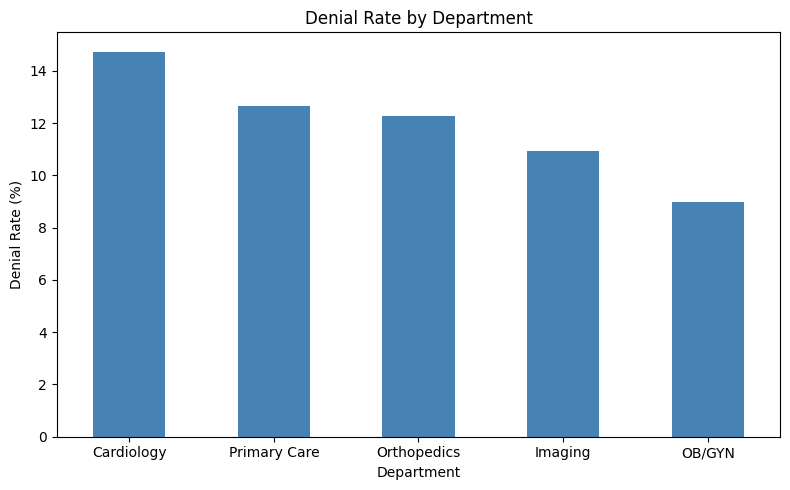

In [39]:
# Plot denial rate by department.
plt.figure(figsize=(8,5))

department_summary["Denial Rate (%)"].plot(
    kind="bar",
    color="steelblue"
)

plt.title("Denial Rate by Department")
plt.xlabel("Department")
plt.ylabel("Denial Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Result

Denial rates varied across departments.

Cardiology had the highest denial rate (14.74%), followed by Primary Care (12.66%) and Orthopedics (12.26%).

Although Primary Care did not have the highest denial rate, it generated the largest number of denied claims because it also had the highest patient volume.

These findings suggest that both denial rate and encounter volume should be considered when prioritizing operational improvement efforts.

## 3.4 Which payer groups have the highest denial rate?

Different payer groups may have different claim denial rates because of variations in coverage policies, eligibility requirements, and billing rules.

Comparing denial rates across payer groups helps identify which insurance categories contribute most to denied claims.

In [40]:
# Count total encounters by payer group.
payer_total = (
    df.groupby("Payer_Group")
      .size()
)

payer_total

Payer_Group
Commercial          1200
Medicaid             561
Medicare             580
Other Government     159
dtype: int64

In [41]:
# Count denied claims by payer group.
payer_denied = (
    df[df["Claim_Denied"] == "Yes"]
      .groupby("Payer_Group")
      .size()
)

payer_denied

Payer_Group
Commercial          143
Medicaid             74
Medicare             66
Other Government     15
dtype: int64

In [42]:
# Calculate denial rate by payer group.
payer_denial_rate = (
    payer_denied
    / payer_total
    * 100
).round(2)

payer_denial_rate.sort_values(ascending=False)

Payer_Group
Medicaid            13.19
Commercial          11.92
Medicare            11.38
Other Government     9.43
dtype: float64

In [43]:
# Combine payer group statistics.
payer_summary = pd.concat(
    [
        payer_total,
        payer_denied,
        payer_denial_rate
    ],
    axis=1
)

payer_summary.columns = [
    "Total Encounters",
    "Denied Claims",
    "Denial Rate (%)"
]

payer_summary = payer_summary.sort_values(
    "Denial Rate (%)",
    ascending=False
)

payer_summary

,Total Encounters,Denied Claims,Denial Rate (%)
Payer_Group,,,
Medicaid,561,74,13.19
Commercial,1200,143,11.92
Medicare,580,66,11.38
Other Government,159,15,9.43


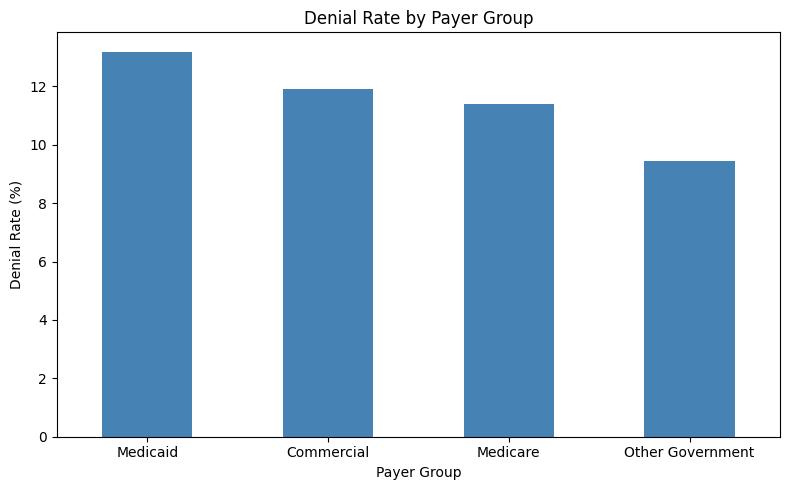

In [44]:
# Plot denial rate by payer group.
plt.figure(figsize=(8,5))

payer_summary["Denial Rate (%)"].plot(
    kind="bar",
    color="steelblue"
)

plt.title("Denial Rate by Payer Group")
plt.xlabel("Payer Group")
plt.ylabel("Denial Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Result

Commercial insurance accounted for the largest number of encounters (1,200) and also generated the highest number of denied claims (143). Although its denial rate (11.92%) was not the highest, its large patient volume means it contributes substantially to the overall denial workload.

Medicaid had the highest denial rate (13.19%), indicating that claims under this payer group were more likely to be denied than those from other payer groups. Medicare showed a similar denial rate (11.38%), while Other Government had the lowest denial rate (9.43%).

Overall, payer group appears to have a moderate association with claim denial. However, because the differences in denial rates are relatively small, payer type alone is unlikely to fully explain the observed denial patterns. Further analysis of operational factors, such as front-end registration issues, is therefore warranted.

## 3.5 Which front-end issues contribute most to claim denials?

Front-end registration errors are often preventable and may contribute directly to claim denials.

This analysis examines the distribution of front-end issue categories among denied claims to identify which operational problems occur most frequently.

In [45]:
# Keep only denied claims.
denied_df = df[df["Claim_Denied"] == "Yes"]

In [46]:
front_end_counts = (
    denied_df["Front_End_Issue"]
    .value_counts()
)

front_end_pct = (
    denied_df["Front_End_Issue"]
    .value_counts(normalize=True)
    * 100
).round(1)

front_end_summary = pd.concat(
    [front_end_counts, front_end_pct],
    axis=1
)

front_end_summary.columns = [
    "Denied Claims",
    "Percent (%)"
]

front_end_summary

,Denied Claims,Percent (%)
Front_End_Issue,,
Incorrect Primary Insurance,87,29.2
Inactive Coverage,80,26.8
No Front-End Issue,48,16.1
Eligibility Not Verified,33,11.1
Member ID Mismatch,29,9.7
Subscriber Information Mismatch,21,7.0


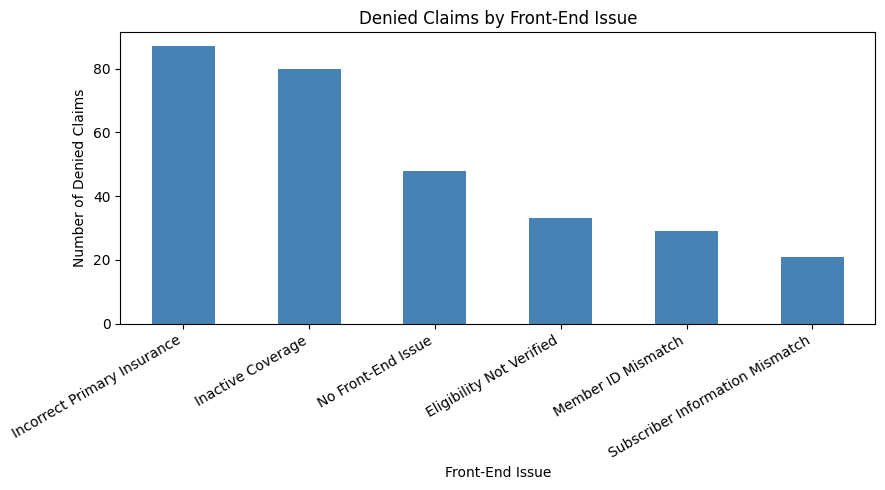

In [47]:
plt.figure(figsize=(9,5))

front_end_summary["Denied Claims"].plot(
    kind="bar",
    color="steelblue"
)

plt.title("Denied Claims by Front-End Issue")
plt.xlabel("Front-End Issue")
plt.ylabel("Number of Denied Claims")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.show()

### Result

Among the denied claims, **Incorrect Primary Insurance** was the most common front-end issue, accounting for **87 denied claims (29.2%)**.

**Inactive Coverage** was the second most frequent issue with **80 denied claims (26.8%)**, indicating that insurance eligibility problems remained a major contributor to claim denials.

Notably, **48 denied claims (16.1%)** occurred even though **no front-end issue was documented**, suggesting that some denials may have resulted from factors outside the registration process, such as payer-specific adjudication rules or downstream claim processing.

The remaining front-end issues—including **Eligibility Not Verified (11.1%)**, **Member ID Mismatch (9.7%)**, and **Subscriber Information Mismatch (7.0%)**—occurred less frequently but still represented preventable registration errors that could potentially be reduced through improved verification workflows.

Nearly 84% of denied claims were associated with a documented front-end issue, highlighting the importance of accurate insurance verification and patient registration.

## 3.6 What drives denial variation across departments?

Department-level denial rates show where denial risk is higher, but they do not explain why those differences occur.

To identify potential operational drivers, I examined the distribution of front-end issues among denied claims within each department.

In [48]:
# Count denied claims by department and front-end issue.
department_issue_counts = pd.crosstab(
    denied_df["Department"],
    denied_df["Front_End_Issue"]
)

department_issue_counts

Front_End_Issue,Eligibility Not Verified,Inactive Coverage,Incorrect Primary Insurance,Member ID Mismatch,No Front-End Issue,Subscriber Information Mismatch
Department,,,,,,
Cardiology,8,17,17,8,7,3
Imaging,3,7,16,5,3,4
OB/GYN,5,12,12,2,13,4
Orthopedics,7,16,13,1,6,1
Primary Care,10,28,29,13,19,9


In [49]:
# Calculate the percentage distribution of front-end issues
# within denied claims for each department.
department_issue_pct = (
    pd.crosstab(
        denied_df["Department"],
        denied_df["Front_End_Issue"],
        normalize="index"
    )
    * 100
).round(1)

department_issue_pct

Front_End_Issue,Eligibility Not Verified,Inactive Coverage,Incorrect Primary Insurance,Member ID Mismatch,No Front-End Issue,Subscriber Information Mismatch
Department,,,,,,
Cardiology,13.3,28.3,28.3,13.3,11.7,5.0
Imaging,7.9,18.4,42.1,13.2,7.9,10.5
OB/GYN,10.4,25.0,25.0,4.2,27.1,8.3
Orthopedics,15.9,36.4,29.5,2.3,13.6,2.3
Primary Care,9.3,25.9,26.9,12.0,17.6,8.3


In [51]:
# Identify all top front-end issues for each department, including ties.

top_issue_rows = []

for department in department_issue_counts.index:
    row_counts = department_issue_counts.loc[department]

    max_count = row_counts.max()

    top_issues = row_counts[row_counts == max_count].index.tolist()

    top_issue_rows.append({
        "Department": department,
        "Top Front-End Issue": " / ".join(top_issues),
        "Denied Claims": max_count,
        "Share of Department Denials (%)":
            department_issue_pct.loc[department, top_issues[0]]
    })

top_issue_by_department = pd.DataFrame(top_issue_rows).set_index("Department")

top_issue_by_department

,Top Front-End Issue,Denied Claims,Share of Department Denials (%)
Department,,,
Cardiology,Inactive Coverage / Incorrect Primary Insurance,17,28.3
Imaging,Incorrect Primary Insurance,16,42.1
OB/GYN,No Front-End Issue,13,27.1
Orthopedics,Inactive Coverage,16,36.4
Primary Care,Incorrect Primary Insurance,29,26.9


### Result

The dominant front-end issue differed by department rather than following a single organization-wide pattern.

- **Cardiology** had two joint leading issues: **Inactive Coverage** and **Incorrect Primary Insurance**, each accounting for **28.3%** of denied claims.
- **Imaging** was strongly concentrated in **Incorrect Primary Insurance**, which accounted for **42.1%** of its denied claims.
- **Orthopedics** was primarily affected by **Inactive Coverage**, representing **36.4%** of denied claims.
- **Primary Care** most frequently experienced **Incorrect Primary Insurance**, accounting for **26.9%** of denied claims.
- **OB/GYN** was different from the other departments: its largest category was **No Front-End Issue (27.1%)**, suggesting that a substantial portion of its denials may not be explained by the registration issues captured in this dataset.

### Business insight

The cross-analysis shows that denial prevention strategies should be tailored by department.

For **Imaging** and **Primary Care**, the strongest opportunity appears to be improving primary/secondary insurance identification and COB-related verification before claim submission.

For **Orthopedics**, the concentration of inactive coverage denials suggests a greater need for timely eligibility verification close to the date of service.

**Cardiology** requires a broader intervention because inactive coverage and incorrect primary insurance contribute equally to its denials.

In contrast, **OB/GYN** has a relatively large share of denials without a documented front-end issue. This suggests that registration-focused interventions alone may have less impact there and that additional downstream denial drivers should be investigated.

## 3.7 What drives denial variation across payer groups?

Payer groups showed different denial rates, but payer type alone does not identify the underlying cause.

To better understand these differences, I examined the distribution of denial reasons within each payer group.

In [52]:
# Count denial reasons within each payer group.
payer_reason_counts = pd.crosstab(
    denied_df["Payer_Group"],
    denied_df["Denial_Reason"]
)

payer_reason_counts

Denial_Reason,Coverage Inactive on Date of Service,Eligibility/Benefit Information Not Confirmed,Member Identification Mismatch,Other Insurance Should Be Primary,Other Non-Preventable Denial,Subscriber Demographic Mismatch
Payer_Group,,,,,,
Commercial,36,14,14,45,27,7
Medicaid,21,9,10,21,9,4
Medicare,18,9,4,19,8,8
Other Government,5,1,1,2,4,2


In [53]:
# Calculate the percentage distribution of denial reasons
# within denied claims for each payer group.
payer_reason_pct = (
    pd.crosstab(
        denied_df["Payer_Group"],
        denied_df["Denial_Reason"],
        normalize="index"
    )
    * 100
).round(1)

payer_reason_pct

Denial_Reason,Coverage Inactive on Date of Service,Eligibility/Benefit Information Not Confirmed,Member Identification Mismatch,Other Insurance Should Be Primary,Other Non-Preventable Denial,Subscriber Demographic Mismatch
Payer_Group,,,,,,
Commercial,25.2,9.8,9.8,31.5,18.9,4.9
Medicaid,28.4,12.2,13.5,28.4,12.2,5.4
Medicare,27.3,13.6,6.1,28.8,12.1,12.1
Other Government,33.3,6.7,6.7,13.3,26.7,13.3


In [54]:
# Identify all top denial reasons for each payer group, including ties.

top_reason_rows = []

for payer in payer_reason_counts.index:
    row_counts = payer_reason_counts.loc[payer]

    max_count = row_counts.max()

    top_reasons = row_counts[row_counts == max_count].index.tolist()

    top_reason_rows.append({
        "Payer Group": payer,
        "Top Denial Reason": " / ".join(top_reasons),
        "Denied Claims": max_count,
        "Share of Payer Denials (%)":
            payer_reason_pct.loc[payer, top_reasons[0]]
    })

top_reason_by_payer = pd.DataFrame(top_reason_rows).set_index("Payer Group")

top_reason_by_payer

,Top Denial Reason,Denied Claims,Share of Payer Denials (%)
Payer Group,,,
Commercial,Other Insurance Should Be Primary,45,31.5
Medicaid,Coverage Inactive on Date of Service / Other I...,21,28.4
Medicare,Other Insurance Should Be Primary,19,28.8
Other Government,Coverage Inactive on Date of Service,5,33.3


### Result

The leading denial reason varied across payer groups.

- **Commercial** claims were most commonly denied because **Other Insurance Should Be Primary**, accounting for **31.5%** of denied commercial claims.
- **Medicaid** had two joint leading denial reasons: **Coverage Inactive on Date of Service** and **Other Insurance Should Be Primary**, each representing **28.4%** of denied Medicaid denials.
- **Medicare** was also primarily affected by **Other Insurance Should Be Primary**, accounting for **28.8%** of denied claims.
- **Other Government** claims were most frequently denied because of **Coverage Inactive on Date of Service**, representing **33.3%** of denied claims.

These findings indicate that the underlying causes of denials differ across payer groups rather than being driven by a single organization-wide issue.

### Business insight

The analysis suggests that denial reduction strategies should be tailored to the characteristics of each payer group.

For **Commercial** and **Medicare** claims, improving coordination of benefits (COB) verification and correctly identifying the primary insurer could prevent a substantial proportion of denials.

For **Medicaid** and **Other Government** payers, eligibility verification immediately before the date of service appears to be particularly important because inactive coverage represents one of the most common denial drivers.

These findings indicate that applying the same registration workflow to every payer group may not be the most effective strategy. Instead, payer-specific verification priorities may improve claim acceptance while reducing front-end rework.

## 3.8 Priority Improvement Opportunities

The previous analyses identified where claim denials occurred and how denial patterns differed across departments, payer groups, and front-end registration issues.

The final step is to translate these findings into operational priorities.

Rather than addressing every issue equally, improvement efforts should focus on areas with the greatest potential to reduce preventable denials while maximizing operational efficiency.

### Financial impact by denial reason

Claim count alone does not reflect the true business impact of denied claims.

To prioritize improvement opportunities, I compared the total denied amount and average denied amount across different denial reasons.

In [57]:
# Summarize financial impact by denial reason.
financial_summary = (
    denied_df.groupby("Denial_Reason")
    .agg(
        Denied_Claims=("Claim_Denied", "count"),
        Total_Denied_Amount=("Denied_Amount", "sum"),
        Average_Denied_Amount=("Denied_Amount", "mean")
    )
    .round(2)
)

financial_summary = financial_summary.sort_values(
    "Total_Denied_Amount",
    ascending=False
)

financial_summary

,Denied_Claims,Total_Denied_Amount,Average_Denied_Amount
Denial_Reason,,,
Other Insurance Should Be Primary,87,32856.25,377.66
Coverage Inactive on Date of Service,80,29376.98,367.21
Other Non-Preventable Denial,48,17832.64,371.51
Eligibility/Benefit Information Not Confirmed,33,12631.65,382.78
Member Identification Mismatch,29,10848.33,374.08
Subscriber Demographic Mismatch,21,9260.92,441.00


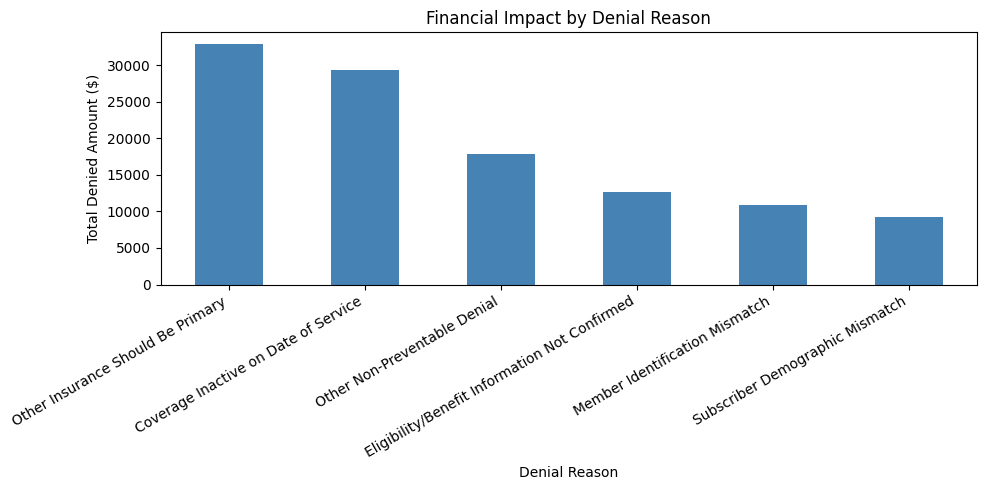

In [59]:
plt.figure(figsize=(10,5))

financial_summary["Total_Denied_Amount"].plot(
    kind="bar",
    color="steelblue"
)

plt.title("Financial Impact by Denial Reason")
plt.xlabel("Denial Reason")
plt.ylabel("Total Denied Amount ($)")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.show()

### Priority 1 — Strengthen insurance verification

Evidence

- Incorrect Primary Insurance was the most common front-end issue.
- It affected multiple departments.
- It contributed substantially to denied reimbursement.

Recommended action

Introduce a standardized insurance verification checklist before claim submission.

### Priority 2 — Expand real-time eligibility verification

Evidence

- Inactive Coverage was consistently observed across Cardiology, Orthopedics, and Medicaid.
- It represented one of the largest financial contributors to denied claims.

Recommended action

Require real-time eligibility (RTE) verification within 72 hours of every scheduled appointment.

### Priority 3 — Implement department-specific workflows

Evidence

Cross-analysis demonstrated that different departments experienced different dominant registration issues.

Recommended action

Develop department-specific registration training instead of applying one standard workflow across all clinics.

### Executive Summary

This analysis demonstrates that preventable claim denials are not evenly distributed across departments, payer groups, or registration issues.

The findings suggest that the greatest operational benefit is likely to come from prioritizing insurance verification, eligibility validation, and department-specific registration workflows rather than applying uniform interventions across the organization.

By focusing improvement efforts on the highest-impact operational issues, healthcare organizations can reduce preventable denials, improve reimbursement efficiency, and better allocate staff training resources.

End of Exploratory Data Analysis

The cleaned dataset and analytical findings will be used to build an interactive Power BI dashboard for operational monitoring and decision support.